In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [4]:
df1 = pd.read_csv('/content/millas_por_galon.csv')
df1[['mpg', 'horsepower']].describe()

,mpg,horsepower
count,398.000000,392.000000
mean,23.514573,104.469388
std,7.815984,38.491160
min,9.000000,46.000000
25%,17.500000,75.000000
50%,23.000000,93.500000
75%,29.000000,126.000000
max,46.600000,230.000000


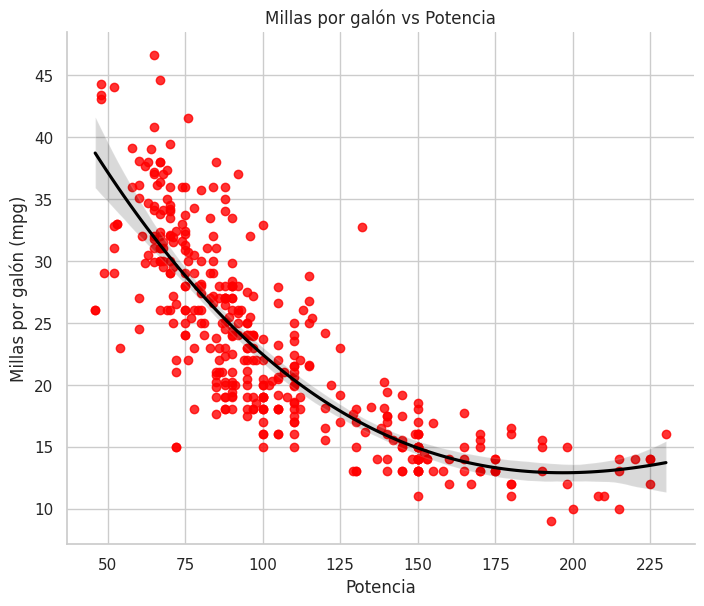

In [5]:
sns.set_theme(style="whitegrid")
datos = df1[['mpg', 'horsepower']].dropna()

sns.lmplot(
    data=datos,
    x='horsepower',
    y='mpg',
    order=3,
    ci=95,
    height=6,
    aspect=1.2,
    scatter_kws={'color': 'red'},
    line_kws={'color': 'black'}
)

plt.xlabel('Potencia')
plt.ylabel('Millas por galón (mpg)')
plt.title('Millas por galón vs Potencia')
plt.show()

IMPRIMIR LA ECUACIÓN...

In [3]:
df = pd.read_csv('/content/general-scan.csv')
df

FileNotFoundError: [Errno 2] No such file or directory: '/content/general-scan.csv'

LOS DATOS ESTAN EN INTERNET..???? NO LOS LEE

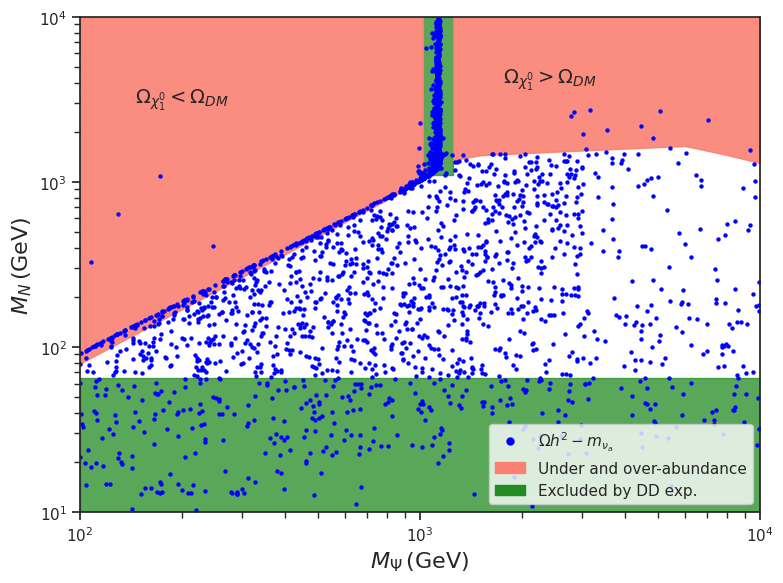

In [8]:
df = pd.read_csv("general-scan.csv")
df["Mpsi"] = df["MDF"]
df["MN"] = df["YRC"] * df["vS"] / np.sqrt(2)
data = df[
    (df["Mpsi"] >= 1e2) &
    (df["Mpsi"] <= 1e4) &
    (df["MN"] >= 1e1) &
    (df["MN"] <= 1e4)
].copy()
allowed = data[
    data["Omega"].between(0.117, 0.123)]
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(8, 6))
ax.axhspan(
    1e1,
    65,
    color="forestgreen",
    alpha=0.75,
    zorder=0)
ax.fill_betweenx(
    [1.1e3, 1e4],
    1.02e3,
    1.25e3,
    color="forestgreen",
    alpha=0.75,
    zorder=0)
x_left = np.logspace(2,np.log10(1.02e3),300)
y_left = 0.5 * x_left**1.1
ax.fill_between(
    x_left,
    y_left,
    1e4,
    color="salmon",
    alpha=0.9,
    zorder=0
)


x_right = np.logspace(
    np.log10(1.25e3),
    4,
    300
)

x_boundary = np.array([
    1.25e3,
    1.5e3,
    3e3,
    6e3,
    1e4
])

y_boundary = np.array([
    1.35e3,
    1.45e3,
    1.55e3,
    1.65e3,
    1.30e3
])

y_right = np.interp(
    np.log10(x_right),
    np.log10(x_boundary),
    y_boundary
)

ax.fill_between(
    x_right,
    y_right,
    1e4,
    color="salmon",
    alpha=0.9,
    zorder=0
)


sns.scatterplot(
    data=allowed,
    x="Mpsi",
    y="MN",
    color="blue",
    s=10,
    linewidth=0,
    ax=ax,
    zorder=2
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1e2, 1e4)
ax.set_ylim(1e1, 1e4)


ax.set_xlabel(
    r"$M_{\Psi}\,(\mathrm{GeV})$",
    fontsize=16
)

ax.set_ylabel(
    r"$M_N\,(\mathrm{GeV})$",
    fontsize=16
)

ax.text(
    1.45e2,
    3e3,
    r"$\Omega_{\chi_1^0}<\Omega_{DM}$",
    fontsize=14
)

ax.text(
    1.75e3,
    4e3,
    r"$\Omega_{\chi_1^0}>\Omega_{DM}$",
    fontsize=14
)

legend_elements = [

    Line2D(
        [],
        [],
        marker="o",
        linestyle="",
        color="blue",
        markersize=5,
        label=r"$\Omega h^2 - m_{\nu_a}$"
    ),

    Patch(
        color="salmon",
        label="Under and over-abundance"
    ),

    Patch(
        color="forestgreen",
        label="Excluded by DD exp."
    )
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.show()

... MY RUTINA DE IA DICE QUE NO ES UN TRABAJO ORIGINAL...

NOTA: 2.3+1.5